In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt


D = "/home/robotserver/wj/go1_antalgic/scripts/rsl_rl/logs/unitree_go1_antalgic/2026_09_04_16_42_52_phase1_s42_P1-002/obs_debug"

raw = pd.read_csv(f"{D}/obs_raw.csv")

In [3]:
raw.head()

,step,env_id,ang_vel_x,ang_vel_y,ang_vel_z,gravity_x,gravity_y,gravity_z,cmd_vx,cmd_vy,...,onehot_RL,onehot_RR,splint_L,lin_vel_x,lin_vel_y,lin_vel_z,calf_q_FL,calf_q_FR,calf_q_RL,calf_q_RR
0,0,102,-0.132960,0.010646,0.020020,0.057469,-0.058538,-0.985149,0.147998,0.021843,...,0,0,0,0.0,0.0,0.0,-1.5,-1.5,-1.5,-1.5
1,0,307,0.008895,0.023461,0.054605,-0.090801,-0.011238,-1.010530,0.360283,-0.035150,...,0,0,0,0.0,0.0,0.0,-1.5,-1.5,-1.5,-1.5
2,0,512,0.007137,0.071159,0.099802,0.020460,0.003682,-1.071990,0.287554,-0.040598,...,0,0,0,0.0,0.0,0.0,-1.5,-1.5,-1.5,-1.5
3,0,716,0.053532,0.023828,-0.024500,-0.020284,0.034189,-0.958232,0.528280,0.078051,...,0,0,0,0.0,0.0,0.0,-1.5,-1.5,-1.5,-1.5
4,0,921,0.033907,0.138097,-0.004703,-0.066662,-0.069242,-0.986725,0.397728,-0.250238,...,0,0,0,0.0,0.0,0.0,-1.5,-1.5,-1.5,-1.5


In [4]:
raw.columns.to_list()

['step',
 'env_id',
 'ang_vel_x',
 'ang_vel_y',
 'ang_vel_z',
 'gravity_x',
 'gravity_y',
 'gravity_z',
 'cmd_vx',
 'cmd_vy',
 'cmd_wz',
 'jpos_hip_FL',
 'jpos_hip_FR',
 'jpos_hip_RL',
 'jpos_hip_RR',
 'jpos_thigh_FL',
 'jpos_thigh_FR',
 'jpos_thigh_RL',
 'jpos_thigh_RR',
 'jpos_calf_FL',
 'jpos_calf_FR',
 'jpos_calf_RL',
 'jpos_calf_RR',
 'jvel_hip_FL',
 'jvel_hip_FR',
 'jvel_hip_RL',
 'jvel_hip_RR',
 'jvel_thigh_FL',
 'jvel_thigh_FR',
 'jvel_thigh_RL',
 'jvel_thigh_RR',
 'jvel_calf_FL',
 'jvel_calf_FR',
 'jvel_calf_RL',
 'jvel_calf_RR',
 'act_hip_FL',
 'act_hip_FR',
 'act_hip_RL',
 'act_hip_RR',
 'act_thigh_FL',
 'act_thigh_FR',
 'act_thigh_RL',
 'act_thigh_RR',
 'act_calf_FL',
 'act_calf_FR',
 'act_calf_RL',
 'act_calf_RR',
 'onehot_FL',
 'onehot_FR',
 'onehot_RL',
 'onehot_RR',
 'splint_L',
 'lin_vel_x',
 'lin_vel_y',
 'lin_vel_z',
 'calf_q_FL',
 'calf_q_FR',
 'calf_q_RL',
 'calf_q_RR']

# Gravitiy

In [5]:
print(f"gravity_x': {raw['gravity_x'].describe().round(2)}")
print(f"gravity_y: {raw['gravity_y'].describe().round(2)}")
print(f"gravity_z: {raw['gravity_z'].describe().round(2)}")

gravity_x': count    1200000.00
mean          -0.04
std            0.07
min           -0.43
25%           -0.09
50%           -0.04
75%            0.00
max            0.59
Name: gravity_x, dtype: float64
gravity_y: count    1200000.00
mean          -0.01
std            0.07
min           -0.72
25%           -0.06
50%           -0.01
75%            0.03
max            0.62
Name: gravity_y, dtype: float64
gravity_z: count    1200000.00
mean          -1.00
std            0.05
min           -1.24
25%           -1.03
50%           -1.00
75%           -0.96
max           -0.65
Name: gravity_z, dtype: float64


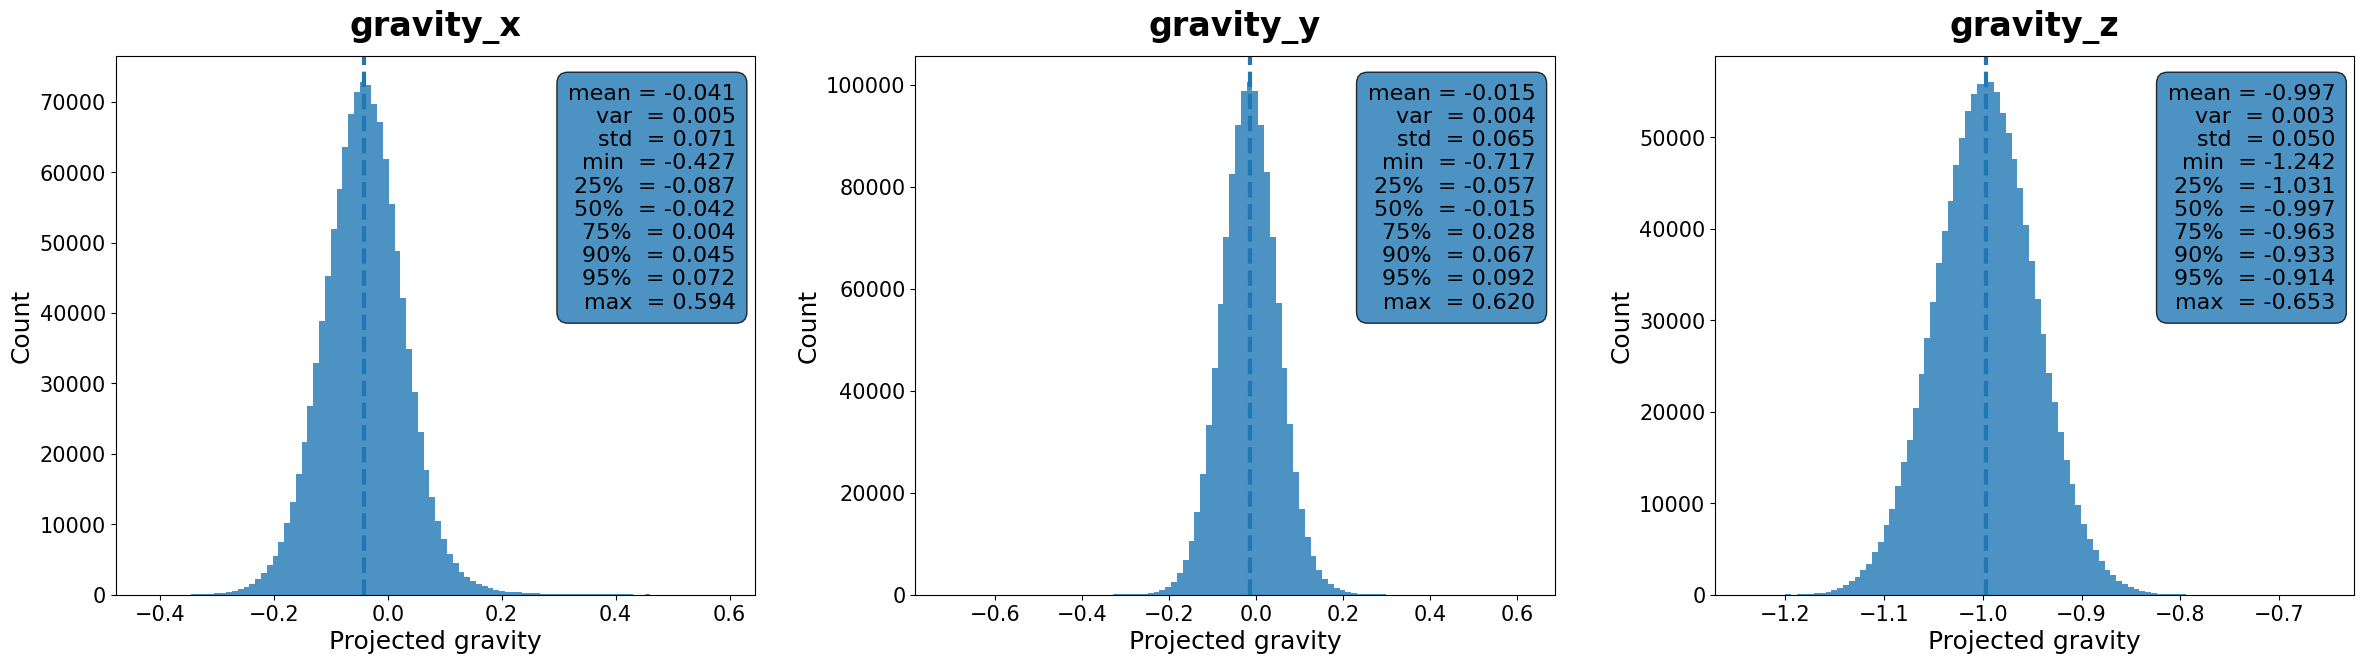

In [10]:
# --------------------------------------------------
# Gravity histogram (1 x 3)
# --------------------------------------------------

gravity_cols = [
    "gravity_x",
    "gravity_y",
    "gravity_z",
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 7)
)

axes = axes.flatten()

for i, col in enumerate(gravity_cols):

    ax = axes[i]

    x = raw[col].dropna()

    # --------------------------------------------------
    # 통계값
    # --------------------------------------------------
    mean_val = x.mean()
    var_val  = x.var(ddof=0)
    std_val  = x.std(ddof=0)

    min_val = x.min()
    q25_val = x.quantile(0.25)
    q50_val = x.quantile(0.50)
    q75_val = x.quantile(0.75)
    q90_val = x.quantile(0.90)
    q95_val = x.quantile(0.95)
    max_val = x.max()

    # --------------------------------------------------
    # Histogram
    # --------------------------------------------------
    ax.hist(
        x,
        bins=100,
        alpha=0.8
    )

    # 평균선
    ax.axvline(
        mean_val,
        linestyle="--",
        linewidth=3
    )

    # --------------------------------------------------
    # 제목
    # --------------------------------------------------
    ax.set_title(
        col,
        fontsize=24,
        fontweight="bold",
        pad=15
    )

    # --------------------------------------------------
    # 축
    # --------------------------------------------------
    ax.set_xlabel(
        "Projected gravity",
        fontsize=18
    )

    ax.set_ylabel(
        "Count",
        fontsize=18
    )

    ax.tick_params(
        axis="both",
        labelsize=15
    )

    # --------------------------------------------------
    # 통계 정보
    # --------------------------------------------------
    stats_text = (
        f"mean = {mean_val:.3f}\n"
        f"var  = {var_val:.3f}\n"
        f"std  = {std_val:.3f}\n"
        f"min  = {min_val:.3f}\n"
        f"25%  = {q25_val:.3f}\n"
        f"50%  = {q50_val:.3f}\n"
        f"75%  = {q75_val:.3f}\n"
        f"90%  = {q90_val:.3f}\n"
        f"95%  = {q95_val:.3f}\n"
        f"max  = {max_val:.3f}"
    )

    ax.text(
        0.97,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=16,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.8
        )
    )

plt.tight_layout(
    pad=2.0,
    w_pad=3.0
)

plt.show()

# Angular velocity

In [15]:
raw.describe().round(2)

,step,env_id,ang_vel_x,ang_vel_y,ang_vel_z,gravity_x,gravity_y,gravity_z,cmd_vx,cmd_vy,...,onehot_RL,onehot_RR,splint_L,lin_vel_x,lin_vel_y,lin_vel_z,calf_q_FL,calf_q_FR,calf_q_RL,calf_q_RR
count,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,...,1200000.0,1200000.0,1200000.0,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00
mean,59999.50,1023.60,0.01,-0.00,0.01,-0.04,-0.01,-1.00,0.52,0.00,...,0.0,0.0,0.0,0.50,0.01,-0.02,-1.22,-1.23,-1.34,-1.17
std,34641.03,588.17,0.58,0.35,0.25,0.07,0.07,0.05,0.27,0.17,...,0.0,0.0,0.0,0.27,0.16,0.09,0.24,0.23,0.22,0.22
min,0.00,102.00,-10.56,-3.82,-2.86,-0.43,-0.72,-1.24,0.00,-0.30,...,0.0,0.0,0.0,-0.53,-0.94,-1.35,-2.61,-2.63,-2.33,-2.26
25%,29999.75,512.00,-0.31,-0.22,-0.18,-0.09,-0.06,-1.03,0.29,-0.14,...,0.0,0.0,0.0,0.28,-0.12,-0.07,-1.34,-1.33,-1.48,-1.31
50%,59999.50,1023.50,0.01,-0.01,0.00,-0.04,-0.01,-1.00,0.52,0.00,...,0.0,0.0,0.0,0.50,0.01,-0.01,-1.15,-1.17,-1.34,-1.14
75%,89999.25,1536.00,0.32,0.22,0.20,0.00,0.03,-0.96,0.75,0.15,...,0.0,0.0,0.0,0.73,0.13,0.04,-1.04,-1.08,-1.19,-0.97
max,119999.00,1945.00,10.72,4.26,2.75,0.59,0.62,-0.65,1.00,0.30,...,0.0,0.0,0.0,1.47,0.95,0.81,-0.88,-0.88,-0.88,-0.88


In [17]:
raw.describe().round(2).iloc[:, 23:35]

,jvel_hip_FL,jvel_hip_FR,jvel_hip_RL,jvel_hip_RR,jvel_thigh_FL,jvel_thigh_FR,jvel_thigh_RL,jvel_thigh_RR,jvel_calf_FL,jvel_calf_FR,jvel_calf_RL,jvel_calf_RR
count,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00,1200000.00
mean,-0.05,0.02,-0.02,0.01,0.22,0.08,-0.11,-0.10,-0.43,-0.15,0.30,0.23
std,1.23,1.22,1.63,1.37,3.01,2.69,1.39,1.27,2.02,2.34,3.02,2.92
min,-17.29,-19.39,-19.16,-19.38,-22.18,-21.27,-13.81,-15.90,-20.10,-20.08,-20.09,-20.06
25%,-0.60,-0.54,-0.71,-0.72,0.02,-0.03,-0.61,-0.65,-1.41,-0.96,-0.76,-0.77
50%,-0.04,0.00,-0.03,-0.03,1.10,0.78,0.07,0.03,-0.43,0.01,0.97,0.57
75%,0.53,0.54,0.70,0.67,2.00,1.58,0.66,0.65,0.59,1.00,2.16,2.05
max,18.20,19.23,24.47,19.12,16.00,16.90,17.11,14.65,20.10,20.09,20.08,20.10


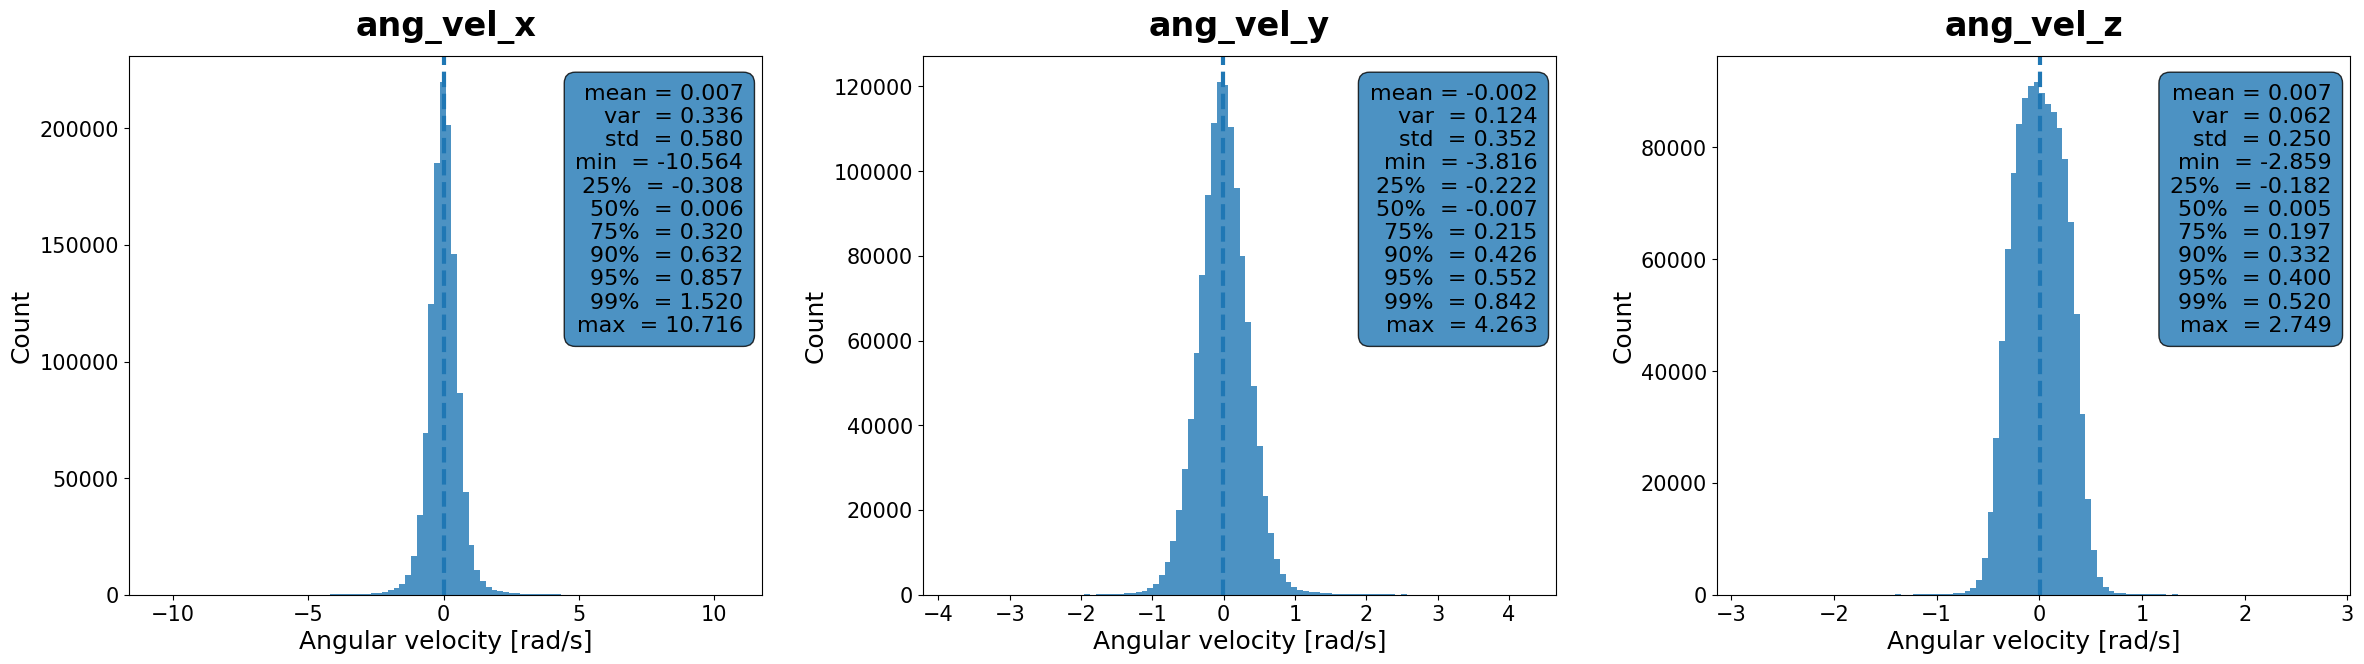

In [7]:
# --------------------------------------------------
# Angular velocity histogram (1 x 3)
# --------------------------------------------------

ang_vel_cols = [
    "ang_vel_x",
    "ang_vel_y",
    "ang_vel_z",
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 7)
)

axes = axes.flatten()

for i, col in enumerate(ang_vel_cols):

    ax = axes[i]

    x = raw[col].dropna()

    # --------------------------------------------------
    # 통계값
    # --------------------------------------------------
    mean_val = x.mean()
    var_val  = x.var(ddof=0)
    std_val  = x.std(ddof=0)

    min_val = x.min()
    q25_val = x.quantile(0.25)
    q50_val = x.quantile(0.50)
    q75_val = x.quantile(0.75)
    q90_val = x.quantile(0.90)
    q95_val = x.quantile(0.95)
    q99_val = x.quantile(0.99)
    max_val = x.max()

    # --------------------------------------------------
    # Histogram
    # --------------------------------------------------
    ax.hist(
        x,
        bins=100,
        alpha=0.8
    )

    # 평균선
    ax.axvline(
        mean_val,
        linestyle="--",
        linewidth=3
    )

    # --------------------------------------------------
    # 제목
    # --------------------------------------------------
    ax.set_title(
        col,
        fontsize=24,
        fontweight="bold",
        pad=15
    )

    # --------------------------------------------------
    # 축
    # --------------------------------------------------
    ax.set_xlabel(
        "Angular velocity [rad/s]",
        fontsize=18
    )

    ax.set_ylabel(
        "Count",
        fontsize=18
    )

    ax.tick_params(
        axis="both",
        labelsize=15
    )

    # --------------------------------------------------
    # 통계 정보
    # --------------------------------------------------
    stats_text = (
        f"mean = {mean_val:.3f}\n"
        f"var  = {var_val:.3f}\n"
        f"std  = {std_val:.3f}\n"
        f"min  = {min_val:.3f}\n"
        f"25%  = {q25_val:.3f}\n"
        f"50%  = {q50_val:.3f}\n"
        f"75%  = {q75_val:.3f}\n"
        f"90%  = {q90_val:.3f}\n"
        f"95%  = {q95_val:.3f}\n"
        f"99%  = {q99_val:.3f}\n"
        f"max  = {max_val:.3f}"
    )

    ax.text(
        0.97,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=16,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.8
        )
    )

plt.tight_layout(
    pad=2.0,
    w_pad=3.0
)

plt.show()

In [9]:
x = raw["ang_vel_x"].dropna()
ratiox = (x > 10).mean() * 100

x = raw["ang_vel_y"].dropna()
ratioy = (x > 4).mean() * 100

x = raw["ang_vel_z"].dropna()
ratioz = (x > 2.5).mean() * 100

print(f"ang_vel_x : {ratiox:5f}%")
print(f"ang_vel_y : {ratioy:5f}%")
print(f"ang_vel_z : {ratioz:5f}%")

ang_vel_x : 0.000083%
ang_vel_y : 0.000667%
ang_vel_z : 0.000083%


# Joint Velocity

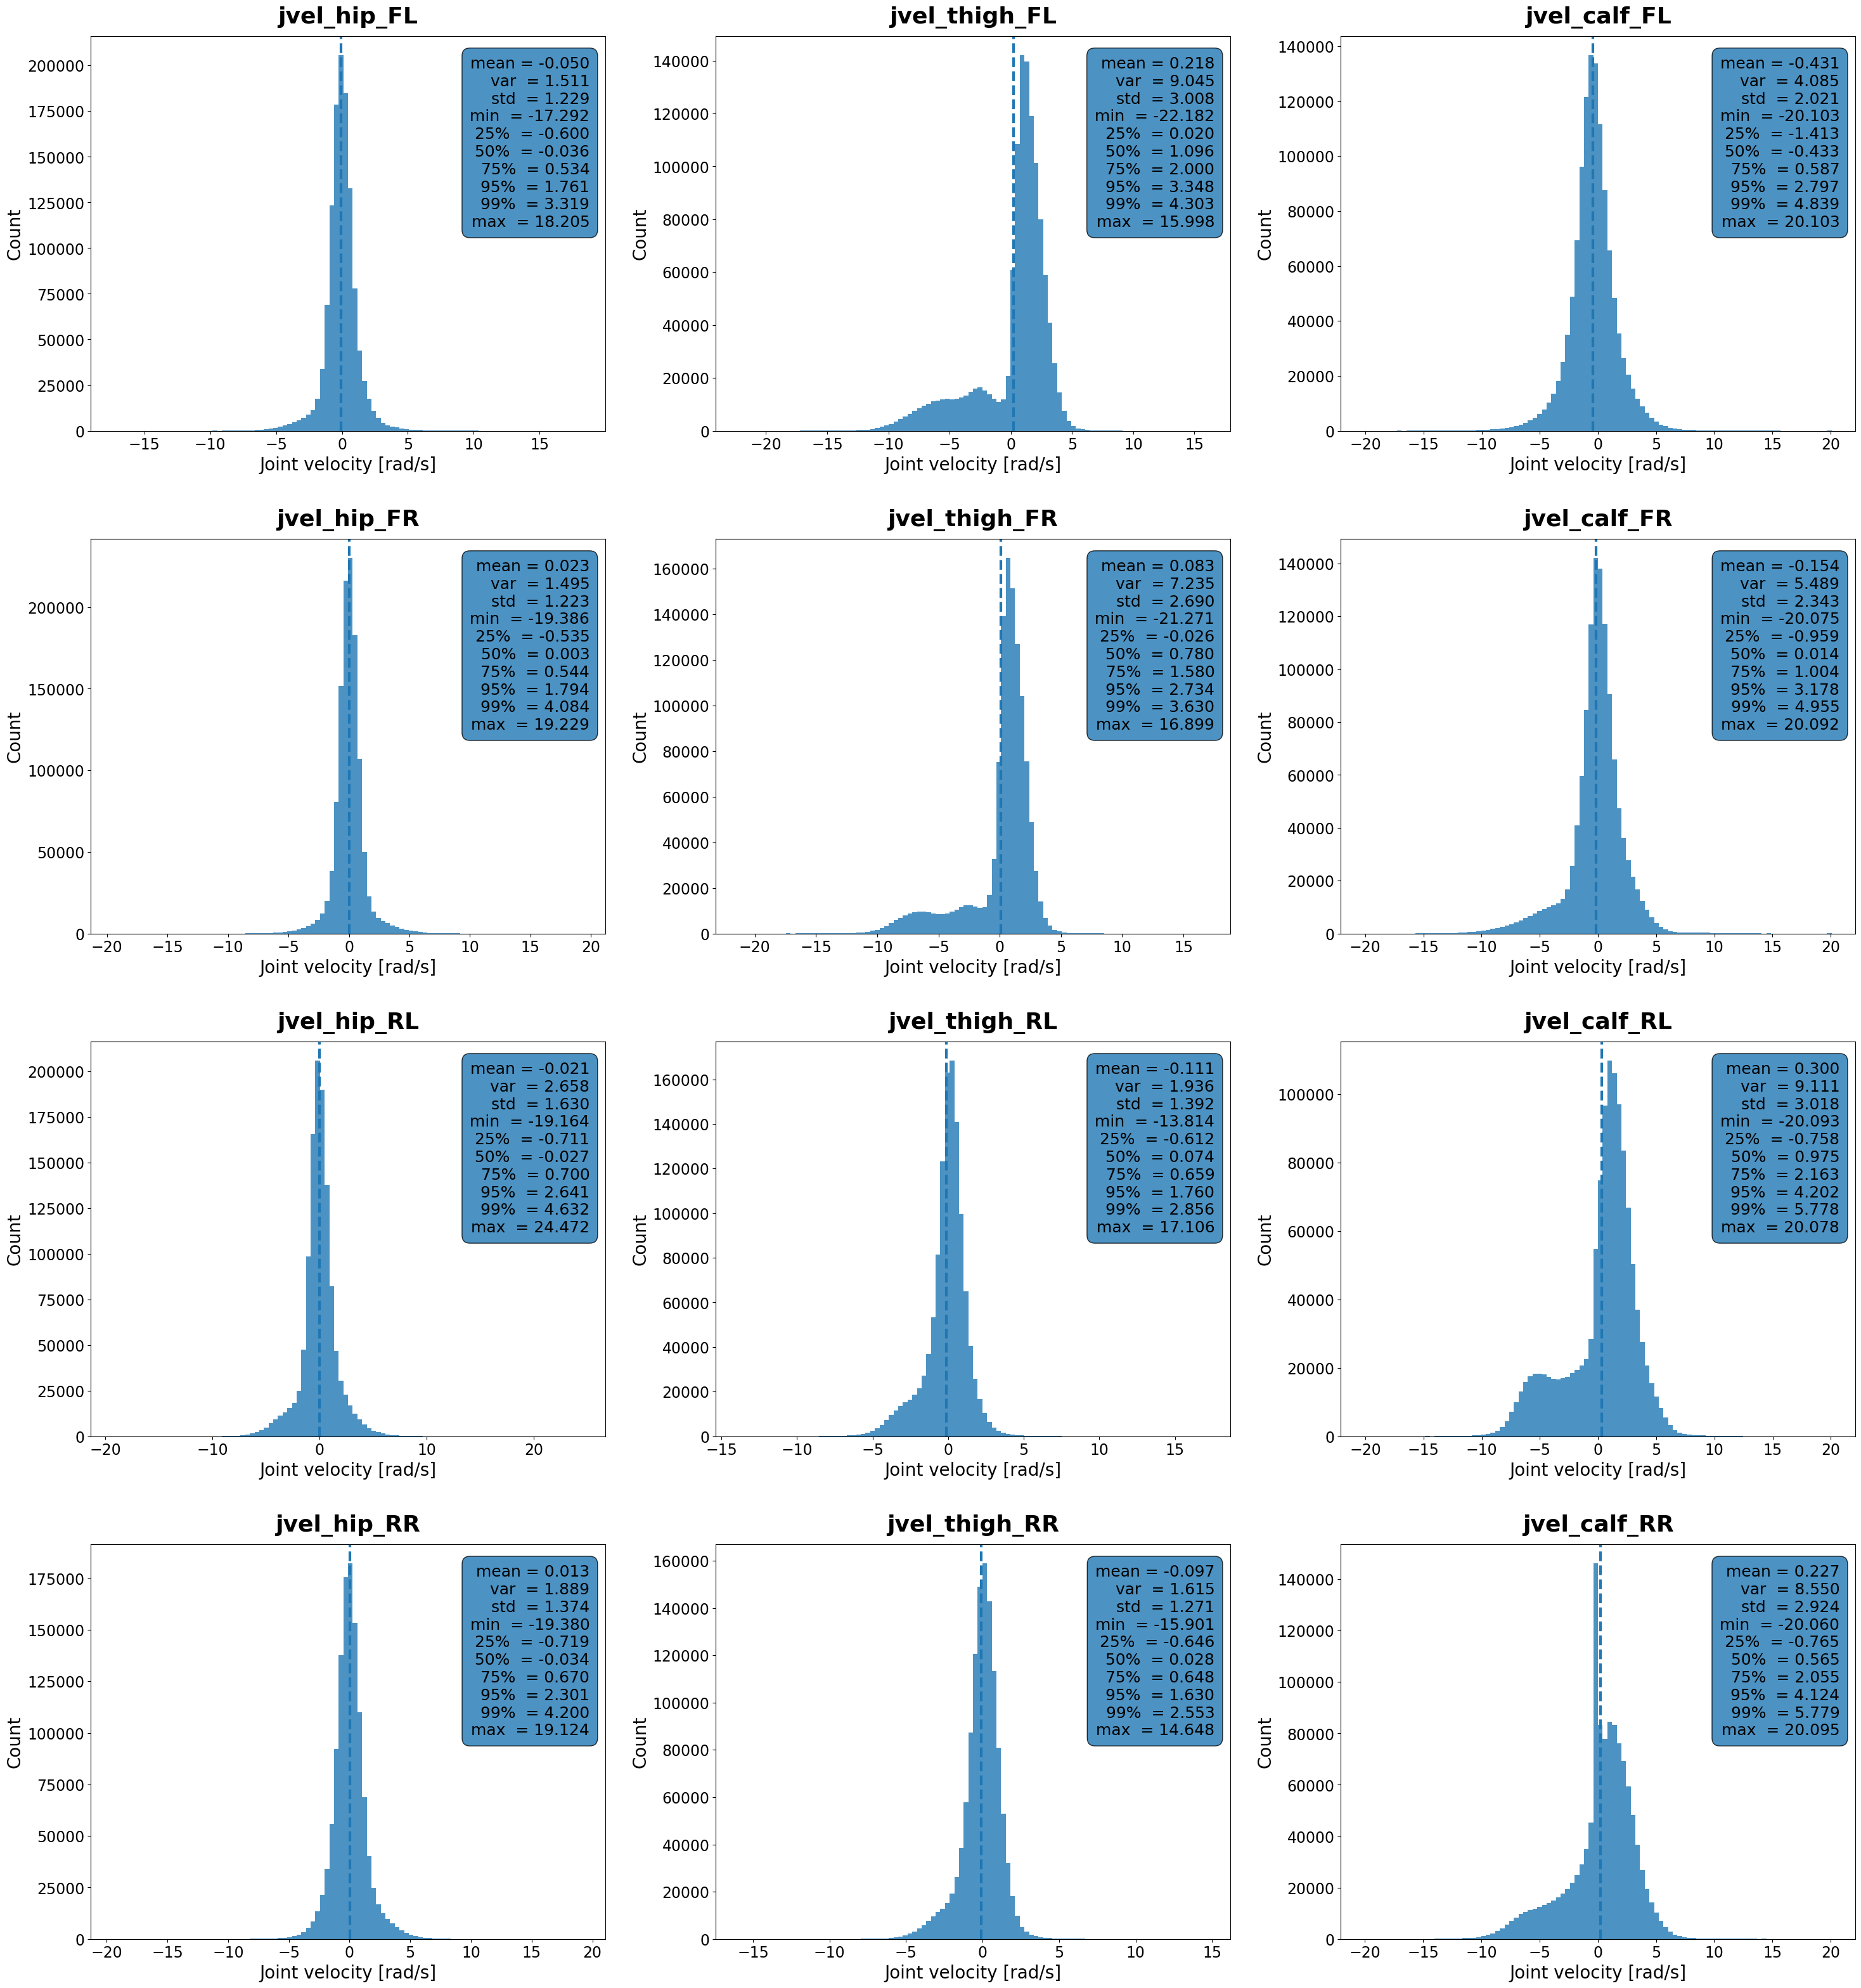

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# STEP 1. 데이터 불러오기
# --------------------------------------------------

D = "/home/robotserver/wj/go1_antalgic/scripts/rsl_rl/logs/unitree_go1_antalgic/2026_09_04_16_42_52_phase1_s42_P1-002/obs_debug"

raw = pd.read_csv(f"{D}/obs_raw.csv")


# --------------------------------------------------
# STEP 2. Plot 순서
# --------------------------------------------------

plot_cols = [
    "jvel_hip_FL",   "jvel_thigh_FL",   "jvel_calf_FL",
    "jvel_hip_FR",   "jvel_thigh_FR",   "jvel_calf_FR",
    "jvel_hip_RL",   "jvel_thigh_RL",   "jvel_calf_RL",
    "jvel_hip_RR",   "jvel_thigh_RR",   "jvel_calf_RR",
]


# --------------------------------------------------
# STEP 3. Joint velocity histogram (4 x 3)
# --------------------------------------------------

fig, axes = plt.subplots(
    4, 3,
    figsize=(30, 32)
)

axes = axes.flatten()


for i, col in enumerate(plot_cols):

    ax = axes[i]

    x = raw[col].dropna()

    # --------------------------------------------------
    # 통계값
    # --------------------------------------------------

    mean_val = x.mean()
    var_val  = x.var(ddof=0)
    std_val  = x.std(ddof=0)

    min_val = x.min()
    q25_val = x.quantile(0.25)
    q50_val = x.quantile(0.50)
    q75_val = x.quantile(0.75)
    q95_val = x.quantile(0.95)
    q99_val = x.quantile(0.99)
    max_val = x.max()


    # --------------------------------------------------
    # Histogram
    # --------------------------------------------------

    ax.hist(
        x,
        bins=100,
        alpha=0.8
    )


    # 평균선
    ax.axvline(
        mean_val,
        linestyle="--",
        linewidth=3
    )


    # --------------------------------------------------
    # 제목
    # --------------------------------------------------

    ax.set_title(
        col,
        fontsize=26,
        fontweight="bold",
        pad=15
    )


    # --------------------------------------------------
    # 축 이름
    # --------------------------------------------------

    ax.set_xlabel(
        "Joint velocity [rad/s]",
        fontsize=20
    )

    ax.set_ylabel(
        "Count",
        fontsize=20
    )


    # --------------------------------------------------
    # 축 눈금 글자 크기
    # --------------------------------------------------

    ax.tick_params(
        axis="both",
        labelsize=17
    )


    # --------------------------------------------------
    # 통계 정보
    # --------------------------------------------------

    stats_text = (
        f"mean = {mean_val:.3f}\n"
        f"var  = {var_val:.3f}\n"
        f"std  = {std_val:.3f}\n"
        f"min  = {min_val:.3f}\n"
        f"25%  = {q25_val:.3f}\n"
        f"50%  = {q50_val:.3f}\n"
        f"75%  = {q75_val:.3f}\n"
        f"95%  = {q95_val:.3f}\n"
        f"99%  = {q99_val:.3f}\n"
        f"max  = {max_val:.3f}"
    )

    ax.text(
        0.97,
        0.95,
        stats_text,

        transform=ax.transAxes,

        fontsize=18,

        verticalalignment="top",
        horizontalalignment="right",

        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.8
        )
    )


# --------------------------------------------------
# subplot 간격
# --------------------------------------------------

plt.tight_layout(
    pad=3.0,
    h_pad=4.0,
    w_pad=3.0
)

plt.show()

# Joint Pos

In [19]:
raw.columns.to_list()[22:]

['jpos_calf_RR',
 'jvel_hip_FL',
 'jvel_hip_FR',
 'jvel_hip_RL',
 'jvel_hip_RR',
 'jvel_thigh_FL',
 'jvel_thigh_FR',
 'jvel_thigh_RL',
 'jvel_thigh_RR',
 'jvel_calf_FL',
 'jvel_calf_FR',
 'jvel_calf_RL',
 'jvel_calf_RR',
 'act_hip_FL',
 'act_hip_FR',
 'act_hip_RL',
 'act_hip_RR',
 'act_thigh_FL',
 'act_thigh_FR',
 'act_thigh_RL',
 'act_thigh_RR',
 'act_calf_FL',
 'act_calf_FR',
 'act_calf_RL',
 'act_calf_RR',
 'onehot_FL',
 'onehot_FR',
 'onehot_RL',
 'onehot_RR',
 'splint_L',
 'lin_vel_x',
 'lin_vel_y',
 'lin_vel_z',
 'calf_q_FL',
 'calf_q_FR',
 'calf_q_RL',
 'calf_q_RR']

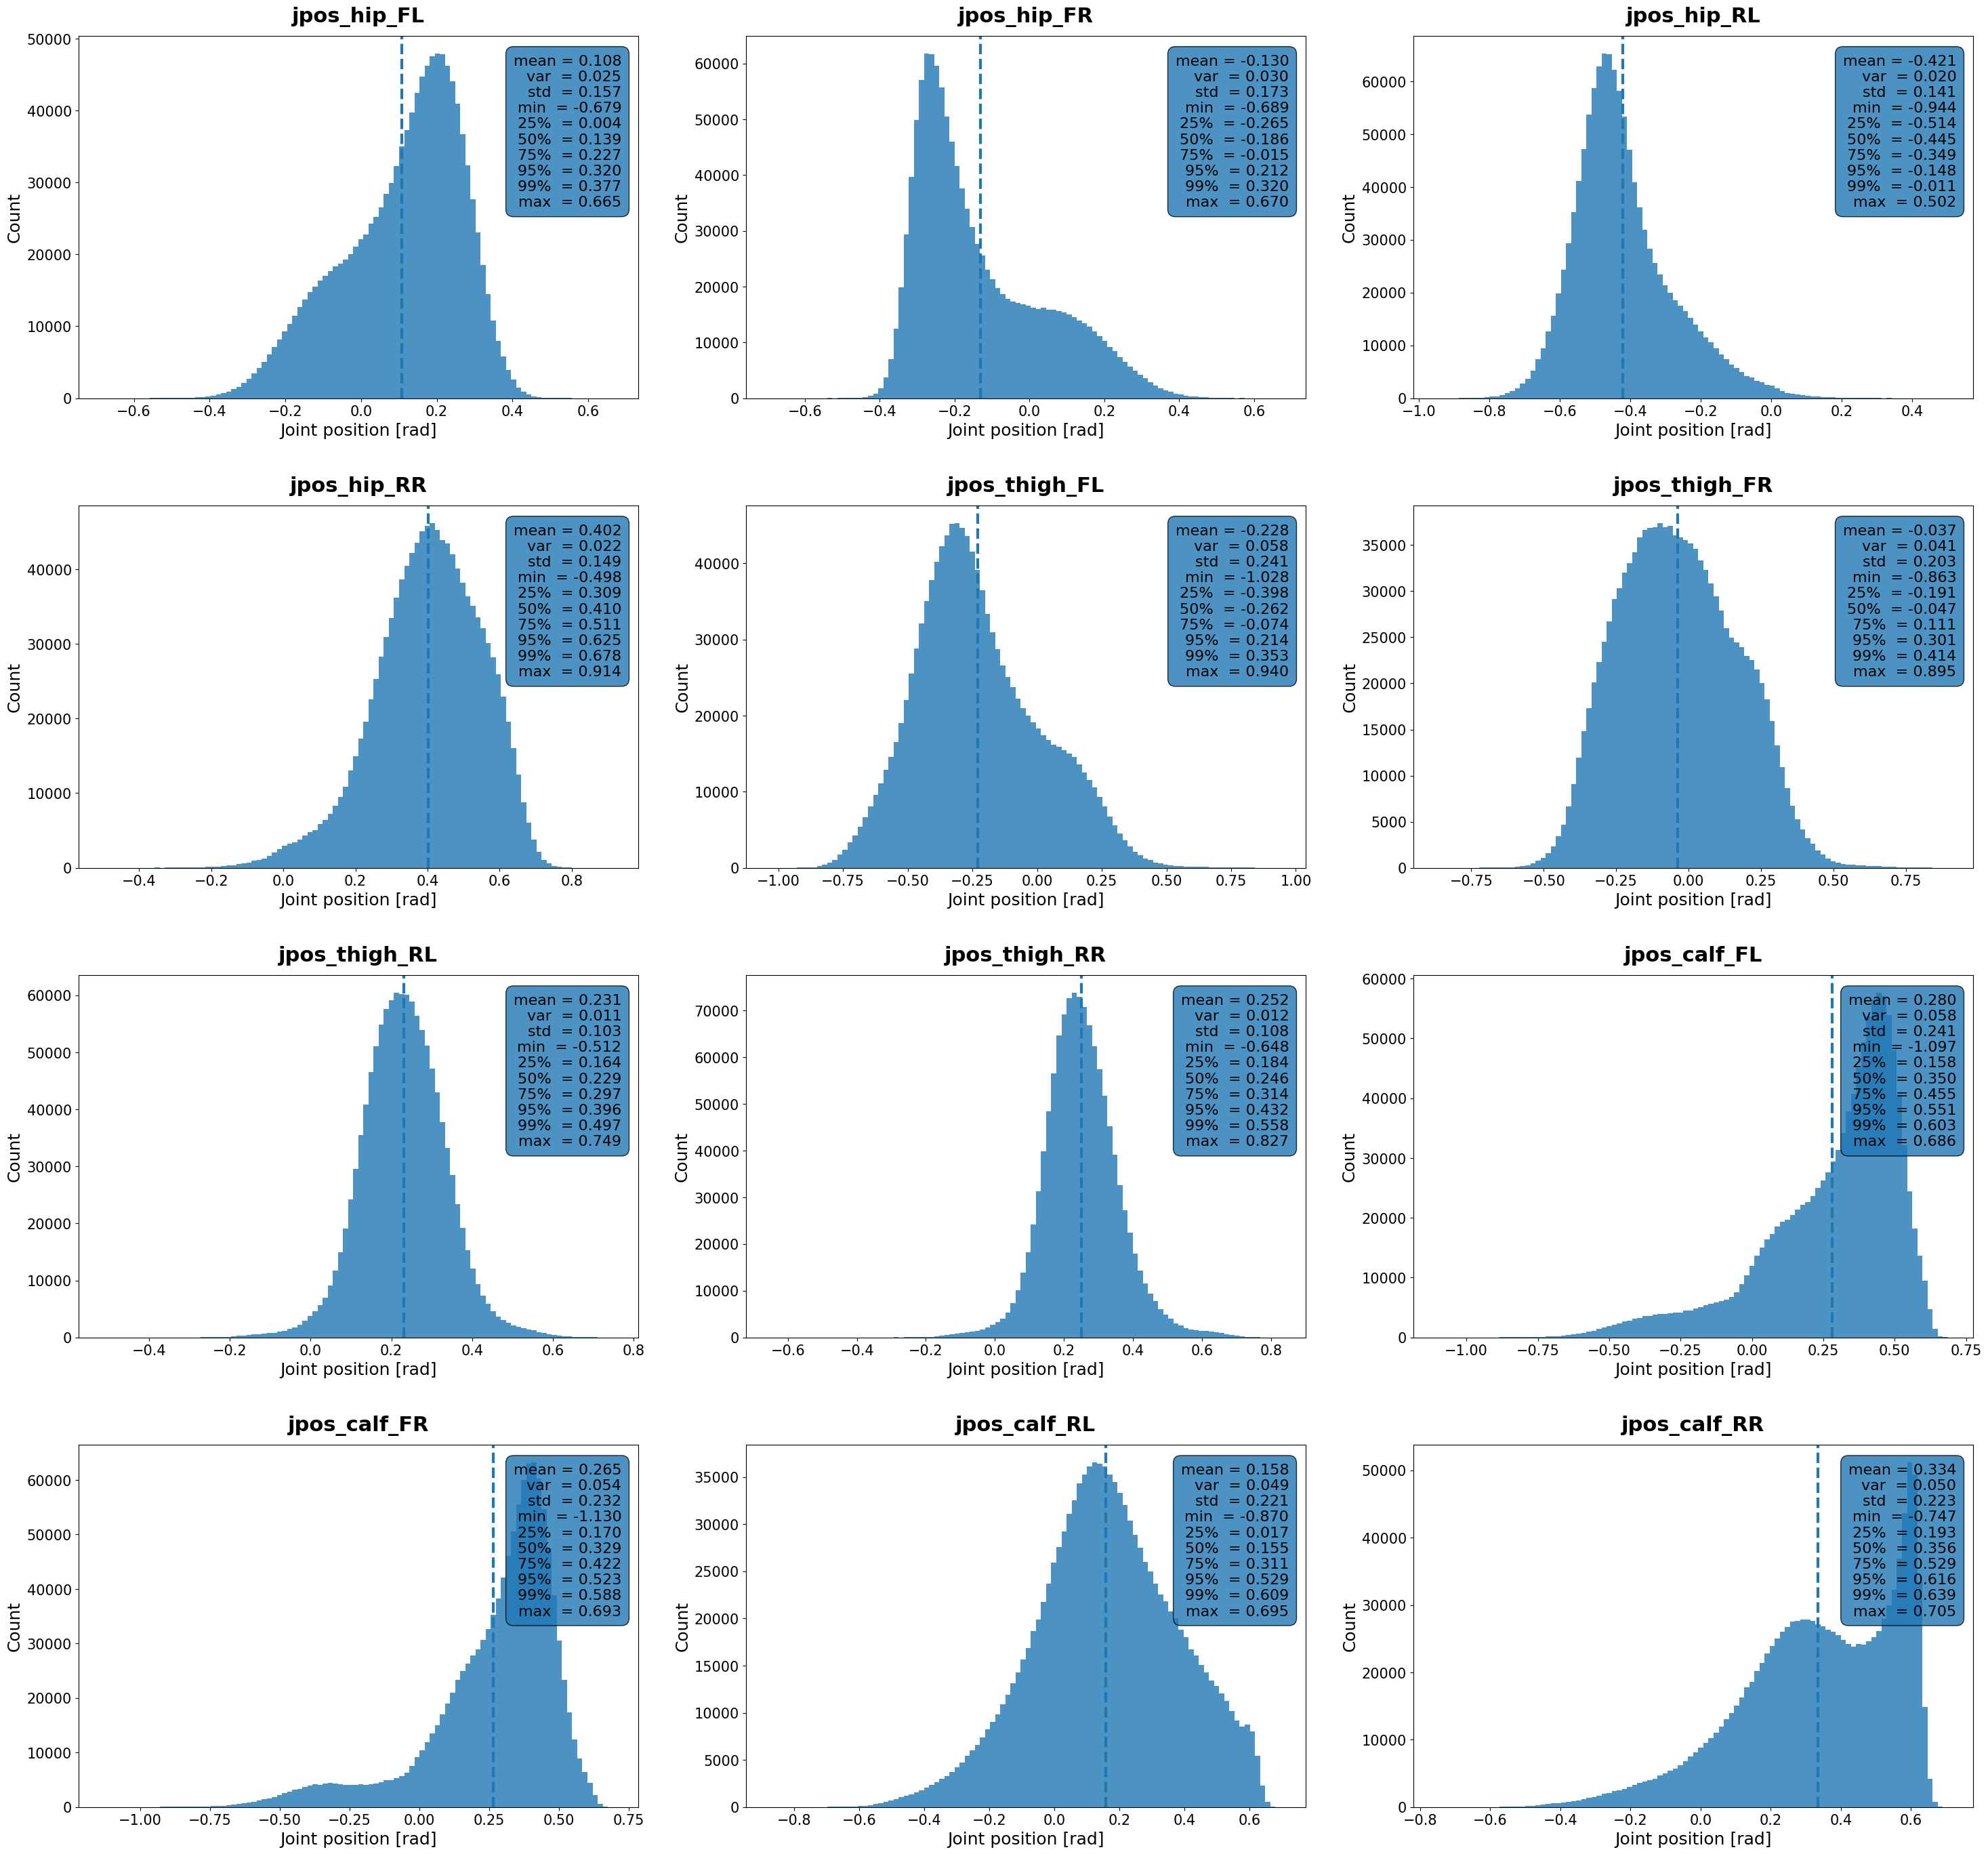

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# --------------------------------------------------
# STEP 1. 데이터 불러오기
# --------------------------------------------------

D = "/home/robotserver/wj/go1_antalgic/scripts/rsl_rl/logs/unitree_go1_antalgic/2026_09_04_16_42_52_phase1_s42_P1-002/obs_debug"

raw = pd.read_csv(f"{D}/obs_raw.csv")


# --------------------------------------------------
# STEP 2. Plot 순서
# --------------------------------------------------

plot_cols = [
    'jpos_hip_FL',
    'jpos_hip_FR',
    'jpos_hip_RL',
    'jpos_hip_RR',

    'jpos_thigh_FL',
    'jpos_thigh_FR',
    'jpos_thigh_RL',
    'jpos_thigh_RR',

    'jpos_calf_FL',
    'jpos_calf_FR',
    'jpos_calf_RL',
    'jpos_calf_RR',
]


# --------------------------------------------------
# STEP 3. subplot 개수 자동 계산
# --------------------------------------------------

n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(30, 7 * n_rows)
)

axes = np.array(axes).flatten()


# --------------------------------------------------
# STEP 4. Histogram
# --------------------------------------------------

for i, col in enumerate(plot_cols):

    ax = axes[i]

    x = raw[col].dropna()

    # 통계값
    mean_val = x.mean()
    var_val  = x.var(ddof=0)
    std_val  = x.std(ddof=0)

    min_val = x.min()
    q25_val = x.quantile(0.25)
    q50_val = x.quantile(0.50)
    q75_val = x.quantile(0.75)
    q95_val = x.quantile(0.95)
    q99_val = x.quantile(0.99)
    max_val = x.max()

    # Histogram
    ax.hist(
        x,
        bins=100,
        alpha=0.8
    )

    # 평균선
    ax.axvline(
        mean_val,
        linestyle="--",
        linewidth=3
    )

    # 제목
    ax.set_title(
        col,
        fontsize=22,
        fontweight="bold",
        pad=15
    )

    # jpos / jvel에 따라 단위 표시
    if col.startswith("jpos"):
        ax.set_xlabel(
            "Joint position [rad]",
            fontsize=18
        )
    else:
        ax.set_xlabel(
            "Joint velocity [rad/s]",
            fontsize=18
        )

    ax.set_ylabel(
        "Count",
        fontsize=18
    )

    ax.tick_params(
        axis="both",
        labelsize=15
    )

    # 통계 정보
    stats_text = (
        f"mean = {mean_val:.3f}\n"
        f"var  = {var_val:.3f}\n"
        f"std  = {std_val:.3f}\n"
        f"min  = {min_val:.3f}\n"
        f"25%  = {q25_val:.3f}\n"
        f"50%  = {q50_val:.3f}\n"
        f"75%  = {q75_val:.3f}\n"
        f"95%  = {q95_val:.3f}\n"
        f"99%  = {q99_val:.3f}\n"
        f"max  = {max_val:.3f}"
    )

    ax.text(
        0.97,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=16,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.8
        )
    )


# --------------------------------------------------
# 남는 subplot 제거
# --------------------------------------------------

for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])


# --------------------------------------------------
# subplot 간격
# --------------------------------------------------

plt.tight_layout(
    pad=3.0,
    h_pad=4.0,
    w_pad=3.0
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# --------------------------------------------------
# STEP 1. 데이터 불러오기
# --------------------------------------------------

D = "/home/robotserver/wj/go1_antalgic/scripts/rsl_rl/logs/unitree_go1_antalgic/2026_09_04_16_42_52_phase1_s42_P1-002/obs_debug"

raw = pd.read_csv(f"{D}/obs_raw.csv")


# --------------------------------------------------
# STEP 2. Plot 순서
# --------------------------------------------------

plot_cols = [
    "jpos_hip_FL",
    "jpos_hip_FR",
    "jpos_hip_RL",
    "jpos_hip_RR",

    "jpos_thigh_FL",
    "jpos_thigh_FR",
    "jpos_thigh_RL",
    "jpos_thigh_RR",

    "jpos_calf_FL",
    "jpos_calf_FR",
    "jpos_calf_RL",
    "jpos_calf_RR",
]


# --------------------------------------------------
# STEP 3. subplot 개수 자동 계산
# --------------------------------------------------

n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(30, 7 * n_rows)
)

axes = np.array(axes).flatten()


# --------------------------------------------------
# STEP 4. Histogram
# 각 값에 0.05를 곱한 분포
# --------------------------------------------------

scale = 0.05

for i, col in enumerate(plot_cols):

    ax = axes[i]

    # 핵심: 원본 값에 0.05 곱하기
    x = raw[col].dropna() * scale

    # --------------------------------------------------
    # 통계값
    # --------------------------------------------------

    mean_val = x.mean()
    var_val  = x.var(ddof=0)
    std_val  = x.std(ddof=0)

    min_val = x.min()
    q25_val = x.quantile(0.25)
    q50_val = x.quantile(0.50)
    q75_val = x.quantile(0.75)
    q95_val = x.quantile(0.95)
    q99_val = x.quantile(0.99)
    max_val = x.max()

    # --------------------------------------------------
    # Histogram
    # --------------------------------------------------

    ax.hist(
        x,
        bins=100,
        alpha=0.8
    )

    # 평균선
    ax.axvline(
        mean_val,
        linestyle="--",
        linewidth=3
    )

    # --------------------------------------------------
    # 제목
    # --------------------------------------------------

    ax.set_title(
        f"{col} × {scale}",
        fontsize=22,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Scaled joint position",
        fontsize=18
    )

    ax.set_ylabel(
        "Count",
        fontsize=18
    )

    ax.tick_params(
        axis="both",
        labelsize=15
    )

    # --------------------------------------------------
    # 통계 정보
    # --------------------------------------------------

    stats_text = (
        f"mean = {mean_val:.4f}\n"
        f"var  = {var_val:.6f}\n"
        f"std  = {std_val:.4f}\n"
        f"min  = {min_val:.4f}\n"
        f"25%  = {q25_val:.4f}\n"
        f"50%  = {q50_val:.4f}\n"
        f"75%  = {q75_val:.4f}\n"
        f"95%  = {q95_val:.4f}\n"
        f"99%  = {q99_val:.4f}\n"
        f"max  = {max_val:.4f}"
    )

    ax.text(
        0.97,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=16,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.8
        )
    )


# --------------------------------------------------
# 남는 subplot 제거
# --------------------------------------------------

for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])


# --------------------------------------------------
# subplot 간격
# --------------------------------------------------

plt.tight_layout(
    pad=3.0,
    h_pad=4.0,
    w_pad=3.0
)

plt.show()

# Command Vel

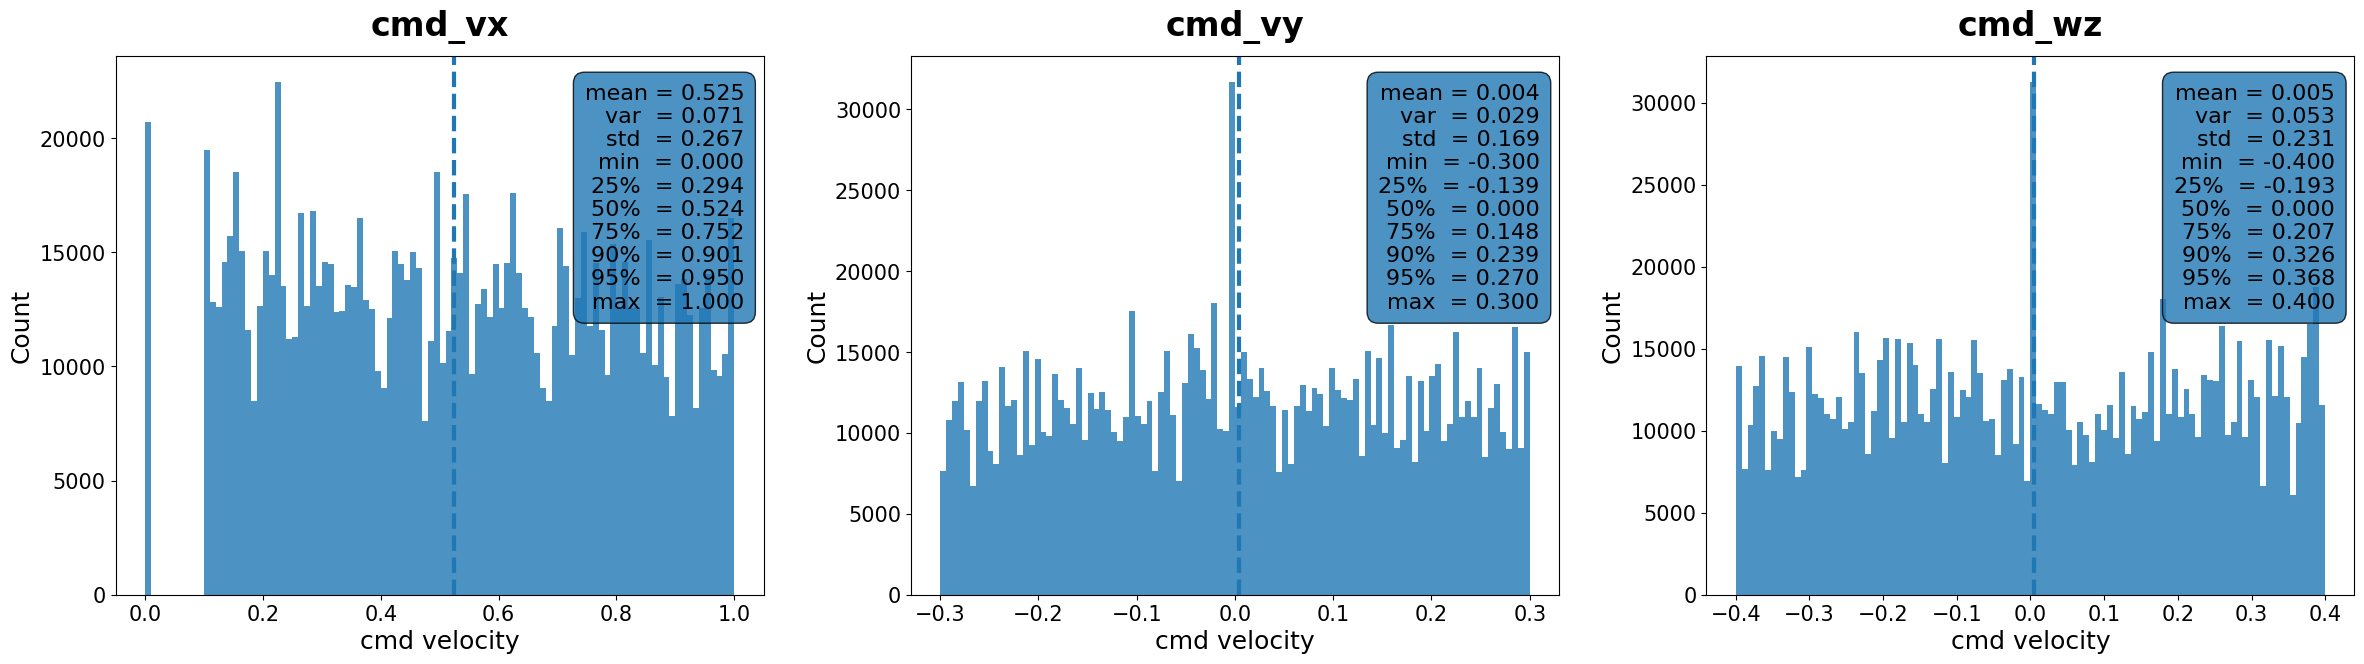

In [20]:
# --------------------------------------------------
# command vel histogram (1 x 3)
# --------------------------------------------------

gravity_cols = [
    "cmd_vx",
    "cmd_vy",
    "cmd_wz",
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 7)
)

axes = axes.flatten()

for i, col in enumerate(gravity_cols):

    ax = axes[i]

    x = raw[col].dropna()

    # --------------------------------------------------
    # 통계값
    # --------------------------------------------------
    mean_val = x.mean()
    var_val  = x.var(ddof=0)
    std_val  = x.std(ddof=0)

    min_val = x.min()
    q25_val = x.quantile(0.25)
    q50_val = x.quantile(0.50)
    q75_val = x.quantile(0.75)
    q90_val = x.quantile(0.90)
    q95_val = x.quantile(0.95)
    max_val = x.max()

    # --------------------------------------------------
    # Histogram
    # --------------------------------------------------
    ax.hist(
        x,
        bins=100,
        alpha=0.8
    )

    # 평균선
    ax.axvline(
        mean_val,
        linestyle="--",
        linewidth=3
    )

    # --------------------------------------------------
    # 제목
    # --------------------------------------------------
    ax.set_title(
        col,
        fontsize=24,
        fontweight="bold",
        pad=15
    )

    # --------------------------------------------------
    # 축
    # --------------------------------------------------
    ax.set_xlabel(
        "cmd velocity",
        fontsize=18
    )

    ax.set_ylabel(
        "Count",
        fontsize=18
    )

    ax.tick_params(
        axis="both",
        labelsize=15
    )

    # --------------------------------------------------
    # 통계 정보
    # --------------------------------------------------
    stats_text = (
        f"mean = {mean_val:.3f}\n"
        f"var  = {var_val:.3f}\n"
        f"std  = {std_val:.3f}\n"
        f"min  = {min_val:.3f}\n"
        f"25%  = {q25_val:.3f}\n"
        f"50%  = {q50_val:.3f}\n"
        f"75%  = {q75_val:.3f}\n"
        f"90%  = {q90_val:.3f}\n"
        f"95%  = {q95_val:.3f}\n"
        f"max  = {max_val:.3f}"
    )

    ax.text(
        0.97,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=16,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.8
        )
    )

plt.tight_layout(
    pad=2.0,
    w_pad=3.0
)

plt.show()

# Action

In [24]:
raw.columns.to_list()[34:]

['jvel_calf_RR',
 'act_hip_FL',
 'act_hip_FR',
 'act_hip_RL',
 'act_hip_RR',
 'act_thigh_FL',
 'act_thigh_FR',
 'act_thigh_RL',
 'act_thigh_RR',
 'act_calf_FL',
 'act_calf_FR',
 'act_calf_RL',
 'act_calf_RR',
 'onehot_FL',
 'onehot_FR',
 'onehot_RL',
 'onehot_RR',
 'splint_L',
 'lin_vel_x',
 'lin_vel_y',
 'lin_vel_z',
 'calf_q_FL',
 'calf_q_FR',
 'calf_q_RL',
 'calf_q_RR']

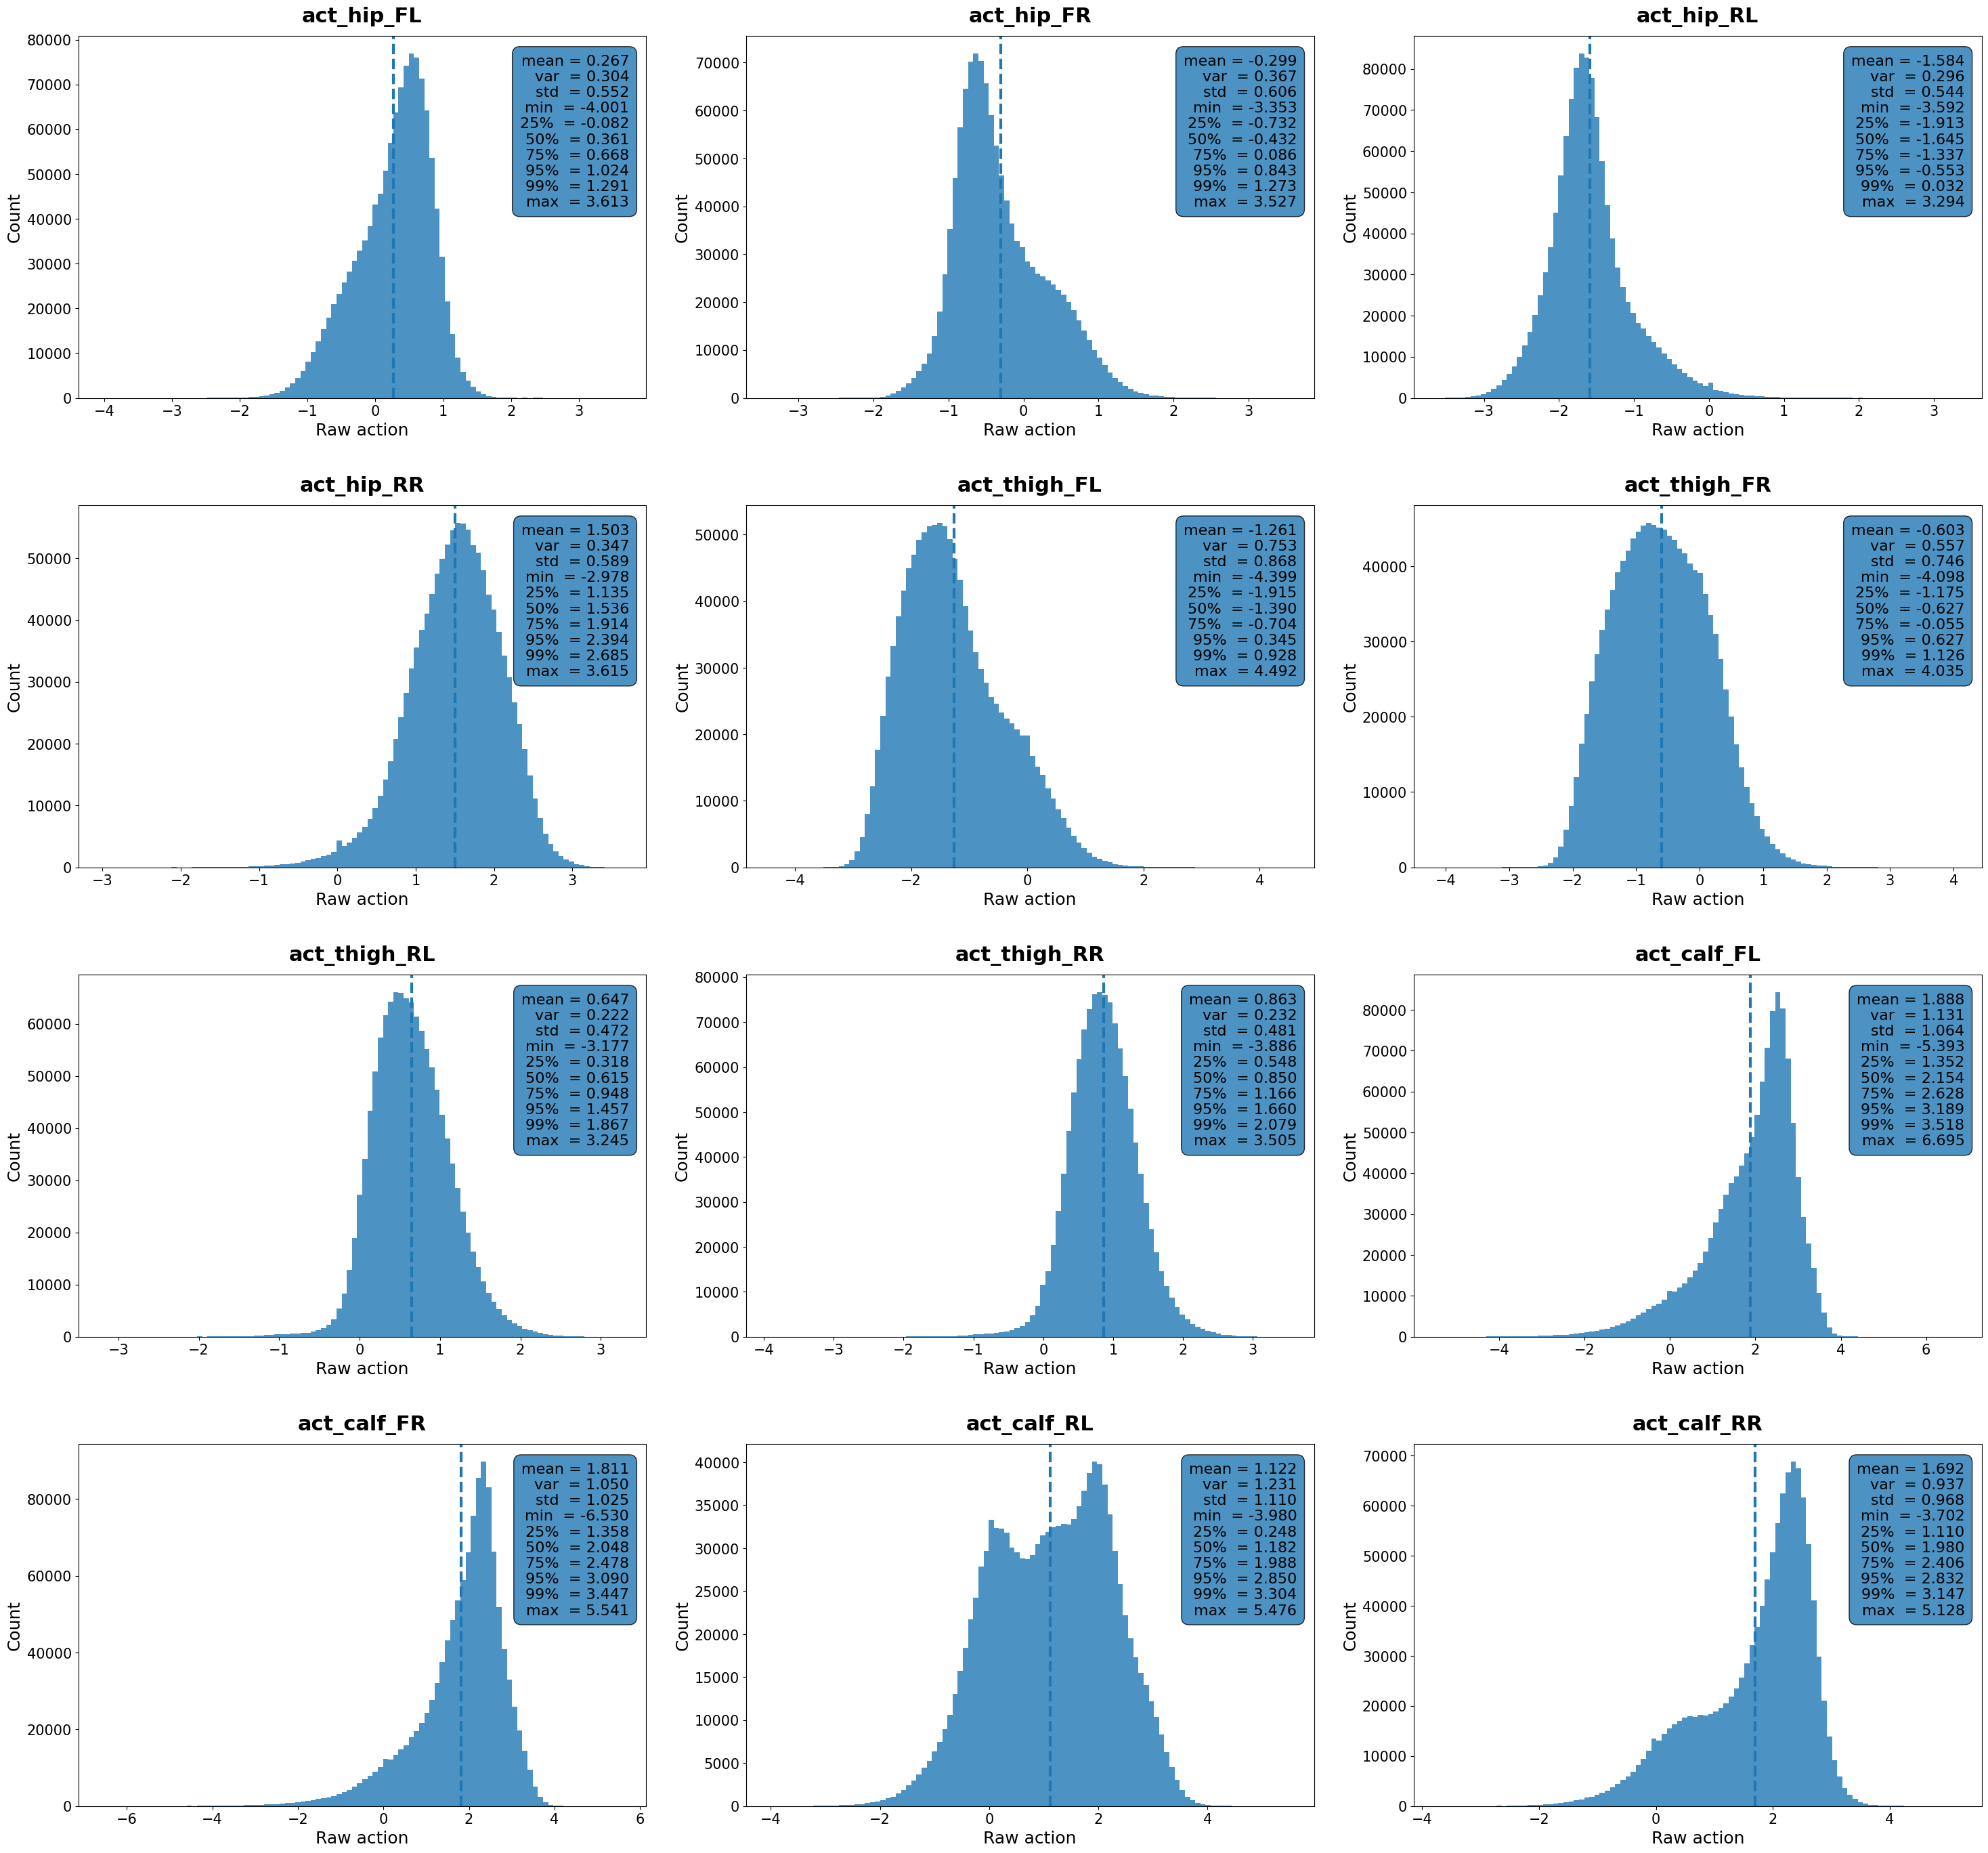

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# --------------------------------------------------
# STEP 1. 데이터 불러오기
# --------------------------------------------------

D = "/home/robotserver/wj/go1_antalgic/scripts/rsl_rl/logs/unitree_go1_antalgic/2026_09_04_16_42_52_phase1_s42_P1-002/obs_debug"

raw = pd.read_csv(f"{D}/obs_raw.csv")


# --------------------------------------------------
# STEP 2. Action column
# --------------------------------------------------

plot_cols = [
    'act_hip_FL',
    'act_hip_FR',
    'act_hip_RL',
    'act_hip_RR',
    'act_thigh_FL',
    'act_thigh_FR',
    'act_thigh_RL',
    'act_thigh_RR',
    'act_calf_FL',
    'act_calf_FR',
    'act_calf_RL',
    'act_calf_RR',
]


# --------------------------------------------------
# STEP 3. subplot
# --------------------------------------------------

n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(30, 7 * n_rows)
)

axes = np.array(axes).flatten()


# --------------------------------------------------
# STEP 4. Histogram
# --------------------------------------------------

for i, col in enumerate(plot_cols):

    ax = axes[i]

    x = raw[col].dropna()

    # 통계값
    mean_val = x.mean()
    var_val = x.var(ddof=0)
    std_val = x.std(ddof=0)

    min_val = x.min()
    q25_val = x.quantile(0.25)
    q50_val = x.quantile(0.50)
    q75_val = x.quantile(0.75)
    q95_val = x.quantile(0.95)
    q99_val = x.quantile(0.99)
    max_val = x.max()

    # Histogram
    ax.hist(
        x,
        bins=100,
        alpha=0.8
    )

    # 평균선
    ax.axvline(
        mean_val,
        linestyle="--",
        linewidth=3,
        label=f"mean = {mean_val:.3f}"
    )

    # 제목
    ax.set_title(
        col,
        fontsize=22,
        fontweight="bold",
        pad=15
    )

    # raw policy action이면 무차원
    ax.set_xlabel(
        "Raw action",
        fontsize=18
    )

    ax.set_ylabel(
        "Count",
        fontsize=18
    )

    ax.tick_params(
        axis="both",
        labelsize=15
    )

    # 통계 정보
    stats_text = (
        f"mean = {mean_val:.3f}\n"
        f"var  = {var_val:.3f}\n"
        f"std  = {std_val:.3f}\n"
        f"min  = {min_val:.3f}\n"
        f"25%  = {q25_val:.3f}\n"
        f"50%  = {q50_val:.3f}\n"
        f"75%  = {q75_val:.3f}\n"
        f"95%  = {q95_val:.3f}\n"
        f"99%  = {q99_val:.3f}\n"
        f"max  = {max_val:.3f}"
    )

    ax.text(
        0.97,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=16,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.8
        )
    )


# --------------------------------------------------
# 남는 subplot 제거
# --------------------------------------------------

for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout(
    pad=3.0,
    h_pad=4.0,
    w_pad=3.0
)

plt.show()

# Linear Vel

In [25]:
raw.columns.to_list()[34:]

['jvel_calf_RR',
 'act_hip_FL',
 'act_hip_FR',
 'act_hip_RL',
 'act_hip_RR',
 'act_thigh_FL',
 'act_thigh_FR',
 'act_thigh_RL',
 'act_thigh_RR',
 'act_calf_FL',
 'act_calf_FR',
 'act_calf_RL',
 'act_calf_RR',
 'onehot_FL',
 'onehot_FR',
 'onehot_RL',
 'onehot_RR',
 'splint_L',
 'lin_vel_x',
 'lin_vel_y',
 'lin_vel_z',
 'calf_q_FL',
 'calf_q_FR',
 'calf_q_RL',
 'calf_q_RR']

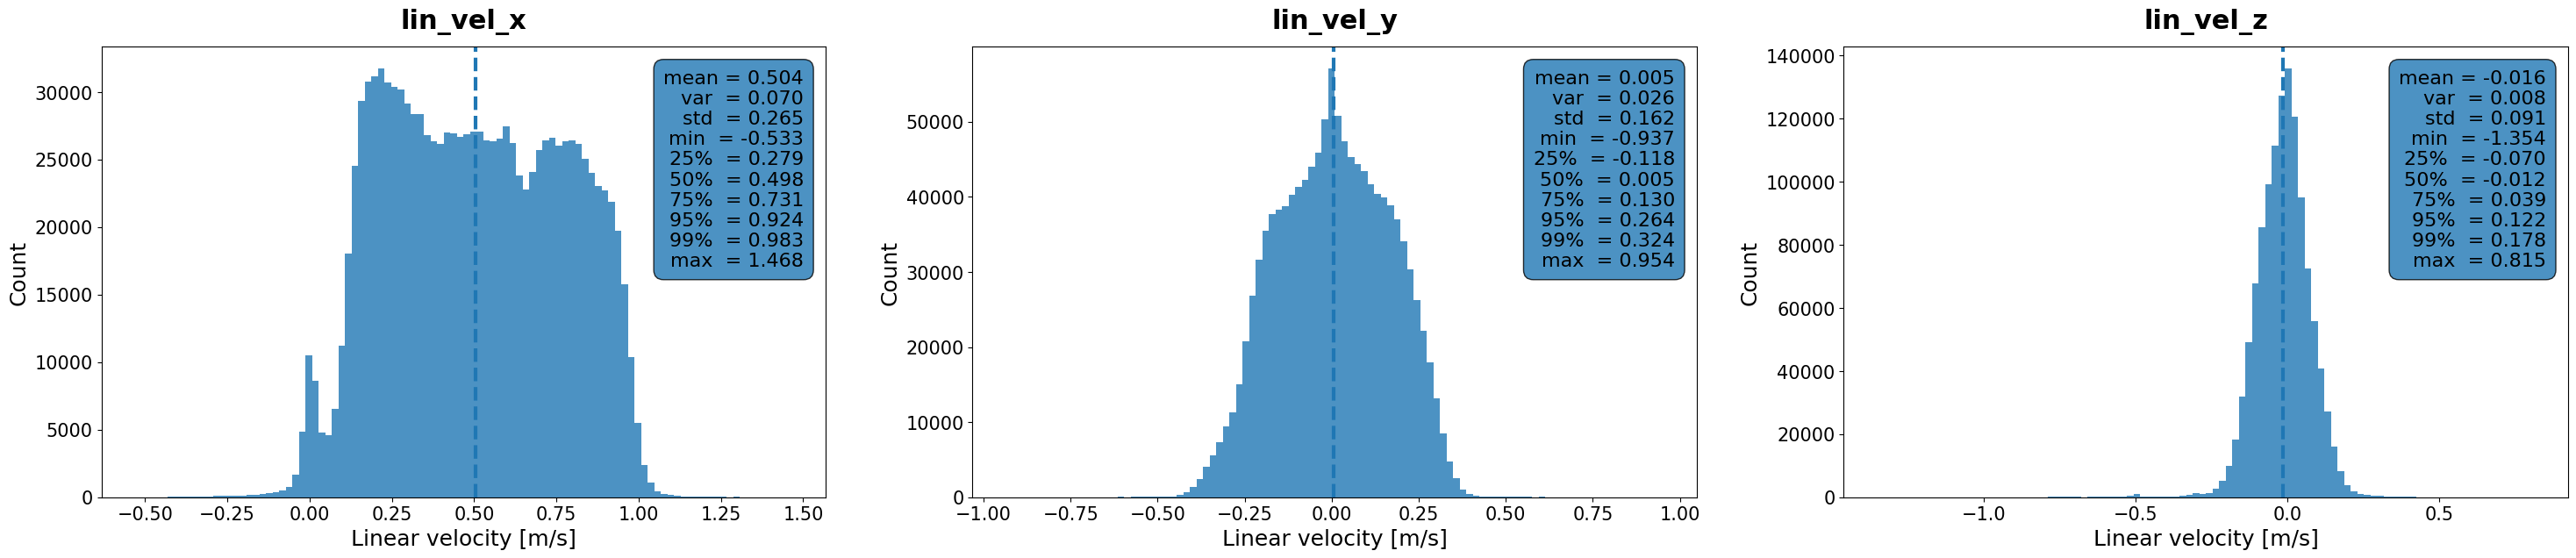

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# --------------------------------------------------
# STEP 1. 데이터 불러오기
# --------------------------------------------------

D = "/home/robotserver/wj/go1_antalgic/scripts/rsl_rl/logs/unitree_go1_antalgic/2026_09_04_16_42_52_phase1_s42_P1-002/obs_debug"

raw = pd.read_csv(f"{D}/obs_raw.csv")


# --------------------------------------------------
# STEP 2. Linear velocity columns
# --------------------------------------------------

plot_cols = [
    'lin_vel_x',
    'lin_vel_y',
    'lin_vel_z',
]


# --------------------------------------------------
# STEP 3. subplot
# --------------------------------------------------

n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(30, 7 * n_rows)
)

axes = np.array(axes).flatten()


# --------------------------------------------------
# STEP 4. Histogram
# --------------------------------------------------

for i, col in enumerate(plot_cols):

    ax = axes[i]

    x = raw[col].dropna()

    # 통계값
    mean_val = x.mean()
    var_val  = x.var(ddof=0)
    std_val  = x.std(ddof=0)

    min_val = x.min()
    q25_val = x.quantile(0.25)
    q50_val = x.quantile(0.50)
    q75_val = x.quantile(0.75)
    q95_val = x.quantile(0.95)
    q99_val = x.quantile(0.99)
    max_val = x.max()

    # Histogram
    ax.hist(
        x,
        bins=100,
        alpha=0.8
    )

    # 평균선
    ax.axvline(
        mean_val,
        linestyle="--",
        linewidth=3
    )

    # 제목
    ax.set_title(
        col,
        fontsize=22,
        fontweight="bold",
        pad=15
    )

    # 선형속도 단위
    ax.set_xlabel(
        "Linear velocity [m/s]",
        fontsize=18
    )

    ax.set_ylabel(
        "Count",
        fontsize=18
    )

    ax.tick_params(
        axis="both",
        labelsize=15
    )

    # 통계 정보
    stats_text = (
        f"mean = {mean_val:.3f}\n"
        f"var  = {var_val:.3f}\n"
        f"std  = {std_val:.3f}\n"
        f"min  = {min_val:.3f}\n"
        f"25%  = {q25_val:.3f}\n"
        f"50%  = {q50_val:.3f}\n"
        f"75%  = {q75_val:.3f}\n"
        f"95%  = {q95_val:.3f}\n"
        f"99%  = {q99_val:.3f}\n"
        f"max  = {max_val:.3f}"
    )

    ax.text(
        0.97,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=16,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.8
        )
    )


plt.tight_layout(
    pad=3.0,
    h_pad=4.0,
    w_pad=3.0
)

plt.show()

# Splint Length

In [3]:
raw.columns.to_list()[40:]

['act_thigh_FR',
 'act_thigh_RL',
 'act_thigh_RR',
 'act_calf_FL',
 'act_calf_FR',
 'act_calf_RL',
 'act_calf_RR',
 'onehot_FL',
 'onehot_FR',
 'onehot_RL',
 'onehot_RR',
 'splint_L',
 'lin_vel_x',
 'lin_vel_y',
 'lin_vel_z',
 'calf_q_FL',
 'calf_q_FR',
 'calf_q_RL',
 'calf_q_RR']

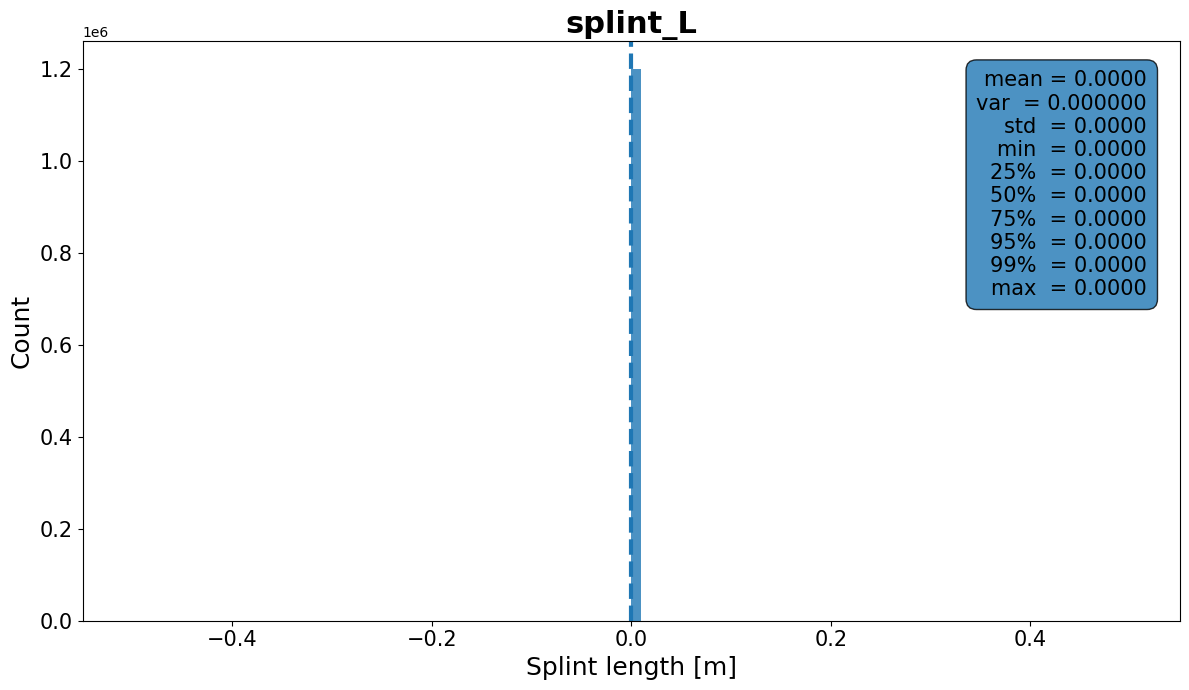

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# STEP 1. 데이터 불러오기
# --------------------------------------------------

D = "/home/robotserver/wj/go1_antalgic/scripts/rsl_rl/logs/unitree_go1_antalgic/2026_09_04_16_42_52_phase1_s42_P1-002/obs_debug"

raw = pd.read_csv(f"{D}/obs_raw.csv")


# --------------------------------------------------
# STEP 2. Splint length
# --------------------------------------------------

x = raw["splint_L"].dropna()


# --------------------------------------------------
# STEP 3. 통계값
# --------------------------------------------------

mean_val = x.mean()
var_val  = x.var(ddof=0)
std_val  = x.std(ddof=0)

min_val = x.min()
q25_val = x.quantile(0.25)
q50_val = x.quantile(0.50)
q75_val = x.quantile(0.75)
q95_val = x.quantile(0.95)
q99_val = x.quantile(0.99)
max_val = x.max()


# --------------------------------------------------
# STEP 4. Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 7))

plt.hist(
    x,
    bins=100,
    alpha=0.8
)

# 평균선
plt.axvline(
    mean_val,
    linestyle="--",
    linewidth=3
)

plt.title(
    "splint_L",
    fontsize=22,
    fontweight="bold"
)

plt.xlabel(
    "Splint length [m]",
    fontsize=18
)

plt.ylabel(
    "Count",
    fontsize=18
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)


# --------------------------------------------------
# 통계값 표시
# --------------------------------------------------

stats_text = (
    f"mean = {mean_val:.4f}\n"
    f"var  = {var_val:.6f}\n"
    f"std  = {std_val:.4f}\n"
    f"min  = {min_val:.4f}\n"
    f"25%  = {q25_val:.4f}\n"
    f"50%  = {q50_val:.4f}\n"
    f"75%  = {q75_val:.4f}\n"
    f"95%  = {q95_val:.4f}\n"
    f"99%  = {q99_val:.4f}\n"
    f"max  = {max_val:.4f}"
)

plt.text(
    0.97,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=15,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.8
    )
)

plt.tight_layout()
plt.show()

# RMS

In [4]:
import numpy as np
import pandas as pd

groups = {

    "linear_vel": [
        "lin_vel_x",
        "lin_vel_y",
        "lin_vel_z",
    ],

    "angular_vel": [
        "ang_vel_x",
        "ang_vel_y",
        "ang_vel_z",
    ],

    "gravity": [
        "gravity_x",
        "gravity_y",
        "gravity_z",
    ],

    "command": [
        "cmd_vx",
        "cmd_vy",
        "cmd_wz",
    ],

    "joint_pos": [
        'jpos_hip_FL',
        'jpos_hip_FR',
        'jpos_hip_RL',
        'jpos_hip_RR',

        'jpos_thigh_FL',
        'jpos_thigh_FR',
        'jpos_thigh_RL',
        'jpos_thigh_RR',

        'jpos_calf_FL',
        'jpos_calf_FR',
        'jpos_calf_RL',
        'jpos_calf_RR',
    ],

    "joint_vel": [
        'jvel_hip_FL',
        'jvel_hip_FR',
        'jvel_hip_RL',
        'jvel_hip_RR',

        'jvel_thigh_FL',
        'jvel_thigh_FR',
        'jvel_thigh_RL',
        'jvel_thigh_RR',

        'jvel_calf_FL',
        'jvel_calf_FR',
        'jvel_calf_RL',
        'jvel_calf_RR',
    ],

    "previous_action": [
        'act_hip_FL',
        'act_hip_FR',
        'act_hip_RL',
        'act_hip_RR',

        'act_thigh_FL',
        'act_thigh_FR',
        'act_thigh_RL',
        'act_thigh_RR',

        'act_calf_FL',
        'act_calf_FR',
        'act_calf_RL',
        'act_calf_RR',
    ],
}


results = []

for group_name, cols in groups.items():

    X = raw[cols].dropna().to_numpy()

    # -----------------------------------------
    # 전체 group의 per-channel RMS
    # -----------------------------------------
    rms = np.sqrt(
        np.mean(X ** 2)
    )

    # -----------------------------------------
    # 각 channel의 std → pooled
    # -----------------------------------------
    std_each = np.std(
        X,
        axis=0,
        ddof=0
    )

    pooled_std = np.sqrt(
        np.mean(std_each ** 2)
    )

    # -----------------------------------------
    # absolute value 기준 95%
    # -----------------------------------------
    q95_abs = np.quantile(
        np.abs(X),
        0.95
    )

    # -----------------------------------------
    # absolute max
    # -----------------------------------------
    max_abs = np.max(
        np.abs(X)
    )

    results.append({
        "group": group_name,
        "dim": len(cols),
        "RMS": rms,
        "pooled_STD": pooled_std,
        "Q95_abs": q95_abs,
        "max_abs": max_abs,

    })


# --------------------------------------------------
# DataFrame 생성
# --------------------------------------------------

result_df = pd.DataFrame(results)


# --------------------------------------------------
# RMS ratio
#
# 각 group RMS를
# 전체 group RMS의 중앙값과 비교
#
# RMS_ratio = RMS_group / median(RMS_groups)
# --------------------------------------------------

reference_rms = result_df["RMS"].median()

result_df["RMS_ratio"] = (
    result_df["RMS"] / reference_rms
)


# --------------------------------------------------
# 결과 출력
# --------------------------------------------------

print(
    f"Reference RMS (median) = {reference_rms:.3f}\n"
)

print(
    result_df.round(3).to_string(index=False)
)

Reference RMS (median) = 0.417

          group  dim   RMS  pooled_STD  Q95_abs  max_abs  RMS_ratio
     linear_vel    3 0.346       0.187    0.822    1.468      0.829
    angular_vel    3 0.417       0.417    0.784   10.716      1.000
        gravity    3 0.580       0.063    1.049    1.242      1.388
        command    3 0.378       0.226    0.847    1.000      0.906
      joint_pos   12 0.323       0.189    0.567    1.130      0.774
      joint_vel   12 2.142       2.133    4.696   24.472      5.131
previous_action   12 1.484       0.787    2.677    6.695      3.556


In [7]:
# joint vel * scaling

import numpy as np
import pandas as pd

groups = {

    "linear_vel": [
        "lin_vel_x",
        "lin_vel_y",
        "lin_vel_z",
    ],

    "angular_vel": [
        "ang_vel_x",
        "ang_vel_y",
        "ang_vel_z",
    ],

    "gravity": [
        "gravity_x",
        "gravity_y",
        "gravity_z",
    ],

    "command": [
        "cmd_vx",
        "cmd_vy",
        "cmd_wz",
    ],

    "joint_pos": [
        'jpos_hip_FL',
        'jpos_hip_FR',
        'jpos_hip_RL',
        'jpos_hip_RR',

        'jpos_thigh_FL',
        'jpos_thigh_FR',
        'jpos_thigh_RL',
        'jpos_thigh_RR',

        'jpos_calf_FL',
        'jpos_calf_FR',
        'jpos_calf_RL',
        'jpos_calf_RR',
    ],

    "joint_vel": [
        'jvel_hip_FL',
        'jvel_hip_FR',
        'jvel_hip_RL',
        'jvel_hip_RR',

        'jvel_thigh_FL',
        'jvel_thigh_FR',
        'jvel_thigh_RL',
        'jvel_thigh_RR',

        'jvel_calf_FL',
        'jvel_calf_FR',
        'jvel_calf_RL',
        'jvel_calf_RR',
    ],

    "previous_action": [
        'act_hip_FL',
        'act_hip_FR',
        'act_hip_RL',
        'act_hip_RR',

        'act_thigh_FL',
        'act_thigh_FR',
        'act_thigh_RL',
        'act_thigh_RR',

        'act_calf_FL',
        'act_calf_FR',
        'act_calf_RL',
        'act_calf_RR',
    ],
}


# --------------------------------------------------
# 그룹별 적용할 scale
# joint_vel에만 0.3 적용
# 나머지는 그대로
# --------------------------------------------------

scale_map = {
    "linear_vel": 1.0,
    "angular_vel": 1.0,
    "gravity": 1.0,
    "command": 1.0,
    "joint_pos": 1.0,
    "joint_vel": 0.23,
    "previous_action": 1.0,
}


results = []

for group_name, cols in groups.items():

    X = raw[cols].dropna().to_numpy()

    # -----------------------------------------
    # scaling 적용
    # joint_vel만 ×0.3
    # -----------------------------------------
    scale = scale_map[group_name]

    X = X * scale

    # -----------------------------------------
    # 전체 group pooled RMS
    # -----------------------------------------
    rms = np.sqrt(
        np.mean(X ** 2)
    )

    # -----------------------------------------
    # 각 channel의 std → pooled
    # -----------------------------------------
    std_each = np.std(
        X,
        axis=0,
        ddof=0
    )

    pooled_std = np.sqrt(
        np.mean(std_each ** 2)
    )

    # -----------------------------------------
    # absolute value 기준 95%
    # -----------------------------------------
    q95_abs = np.quantile(
        np.abs(X),
        0.95
    )

    # -----------------------------------------
    # absolute max
    # -----------------------------------------
    max_abs = np.max(
        np.abs(X)
    )

    results.append({
        "group": group_name,
        "dim": len(cols),
        "scale": scale,
        "RMS": rms,
        "pooled_STD": pooled_std,
        "Q95_abs": q95_abs,
        "max_abs": max_abs,
    })


# --------------------------------------------------
# DataFrame 생성
# --------------------------------------------------

result_df = pd.DataFrame(results)


# --------------------------------------------------
# scaling 적용 후 RMS median 재계산
# --------------------------------------------------

reference_rms = result_df["RMS"].median()

result_df["RMS_ratio"] = (
    result_df["RMS"] / reference_rms
)


# --------------------------------------------------
# 결과 출력
# --------------------------------------------------

print(
    f"Reference RMS (median) = {reference_rms:.3f}\n"
)

print(
    result_df.round(3).to_string(index=False)
)

Reference RMS (median) = 0.417

          group  dim  scale   RMS  pooled_STD  Q95_abs  max_abs  RMS_ratio
     linear_vel    3   1.00 0.346       0.187    0.822    1.468      0.829
    angular_vel    3   1.00 0.417       0.417    0.784   10.716      1.000
        gravity    3   1.00 0.580       0.063    1.049    1.242      1.388
        command    3   1.00 0.378       0.226    0.847    1.000      0.906
      joint_pos   12   1.00 0.323       0.189    0.567    1.130      0.774
      joint_vel   12   0.23 0.493       0.491    1.080    5.629      1.180
previous_action   12   1.00 1.484       0.787    2.677    6.695      3.556
